# 🚀 Mission 7: Extend the Analysis

```{admonition} Your mission
:class: tip

Your maps revealed that canopy structure varies across Berlin.

Now we follow a new clue:

> **Does canopy structure differ between Local Climate Zones?**

In this mission, you will:

- 🏙️ connect canopy structure with urban form
- 📊 compare Local Climate Zones
- 🔎 identify differences between groups
- 🧠 develop a new research question

🏅 **Badge to unlock:** Urban Pattern Analyst

# 🏙️ Follow the LCZ clue

**Local Climate Zones (LCZs)** classify areas according to characteristics such as building form, land cover, and urban structure.

>Our dataset assigns an LCZ class to each 100 m grid cell.

Let's see which classes occur in the Berlin data.

In [2]:
import geopandas as gpd

berlin = gpd.read_file(
    "data/g_raw/berlin_3D_canopy_stats_lczv3_grid100m_urau2021_epsg25833.gpkg"
)
berlin["lcz_class_value"].value_counts().sort_index()

/opt/conda/envs/worker_env/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(


lcz_class_value
0        10
1       335
2      2832
3       444
4      2760
5      9811
6     33287
8      6042
9      1977
10      472
11    18603
12     6581
14     3312
15       31
16       12
17     4021
Name: count, dtype: int64

# 🌳 Compare canopy structure

In Mission 6, we created an approximate **mean canopy height** from canopy volume and canopy area.

Now we can summarise this indicator for each Local Climate Zone.

Let's calculate it again here so Mission 7 remains reproducible

In [3]:
berlin["mean_canopy_height"] = (
    berlin["chm_volume"] / berlin["chm_area"]
)

berlin.loc[
    berlin["chm_area"] == 0,
    "mean_canopy_height"
] = None

In [4]:
lcz_canopy = (
    berlin.groupby("lcz_class_value")["mean_canopy_height"]
    .agg(["count", "mean", "median"])
    .round(2)
)

lcz_canopy

,count,mean,median
lcz_class_value,,,
0,10,9.09,8.68
1,324,9.46,9.03
2,2822,10.79,10.81
3,434,8.99,8.95
4,2759,10.55,10.62
5,9809,10.76,10.78
6,33260,9.62,9.35
8,5669,8.62,8.49
9,1954,10.93,10.52


# 🔎 Read the evidence

The table gives us three useful pieces of information:

>- **count** → number of grid cells in each LCZ
>- **mean** → average canopy height
>- **median** → the middle canopy-height value

Now we can ask whether some urban forms tend to contain taller canopy structures than others.

# 📊 Make the comparison visible

A chart makes differences between LCZ classes easier to compare.

We will use the **median** because it represents a typical value without being strongly influenced by a few unusually high observations.

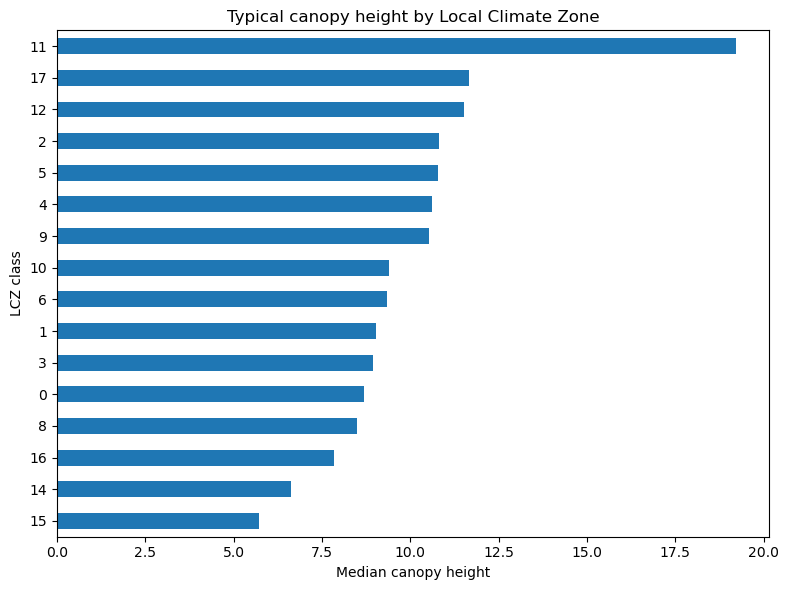

In [13]:
import matplotlib.pyplot as plt

median_by_lcz = (
    berlin.groupby("lcz_class_value")["mean_canopy_height"]
    .median()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 6))

median_by_lcz.plot(
    kind="barh",
    ax=ax
)

ax.set_title("Typical canopy height by Local Climate Zone")
ax.set_xlabel("Median canopy height")
ax.set_ylabel("LCZ class")

plt.tight_layout()
plt.show()

In [14]:
#| tags: [remove-input]

from IPython.display import HTML, display
from pathlib import Path

# Save files into the Jupyter Book static folder
download_dir = Path.cwd() / "_static" / "g_output"
download_dir.mkdir(parents=True, exist_ok=True)

output1_png = download_dir / "canopy_height_by_LCZ.png"
fig.savefig(output1_png, dpi=300, bbox_inches="tight")


display(
    HTML(
        """
<div style="margin-top: 1em; margin-bottom: 1em;">

    <a href="../_static/g_output/canopy_height_by_LCZ.png" download
       style="display: inline-block; background-color: #2E7D32; color: white; padding: 10px 14px; text-decoration: none; border-radius: 6px; font-weight: bold; margin-right: 10px;">
       ⬇️ Download PNG
    </a>

</div>
"""
    )
)

```{admonition} 🕵️ Investigator challenge
:class: note

Study the chart.

Can you identify:

- 🌳 the LCZ with the tallest typical canopy?
- 🌱 the LCZ with the lowest typical canopy?
- 🔎 classes with similar canopy structures?

**What does this suggest about the relationship between urban form and vegetation structure?**

# 🧠 But averages can hide variation

>Two LCZ classes can have similar median values while containing very different individual observations.

To see this variation, we need to look beyond a single summary value.

>A boxplot is useful here and introduces only one new visual concept.

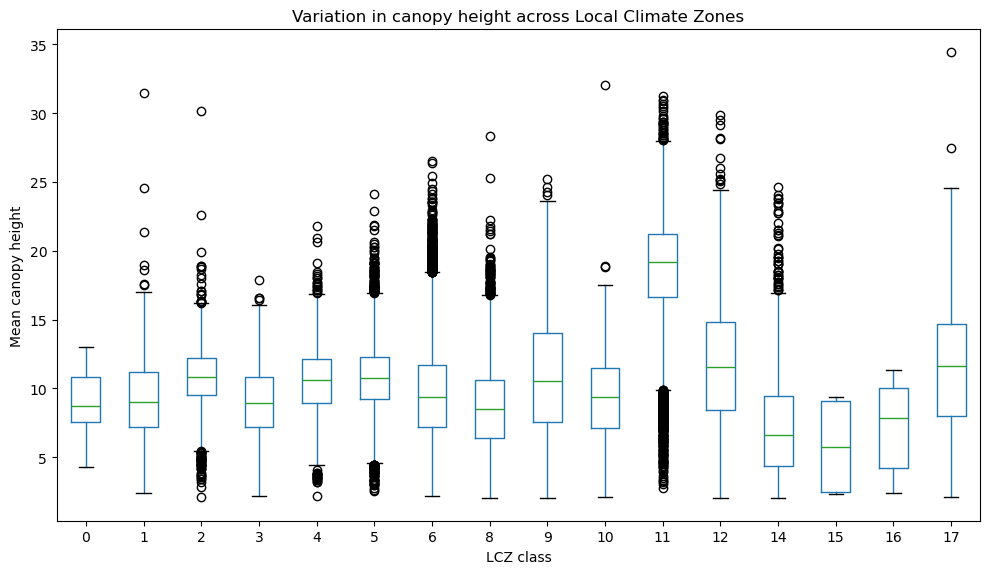

In [15]:
berlin.boxplot(
    column="mean_canopy_height",
    by="lcz_class_value",
    figsize=(10, 6),
    grid=False
)

plt.title("Variation in canopy height across Local Climate Zones")
plt.suptitle("")
plt.xlabel("LCZ class")
plt.ylabel("Mean canopy height")

plt.tight_layout()
plt.show()

# 📦 How to read the boxplot

Each box summarises the distribution of canopy heights within one LCZ.

Look for:

>- the **line inside the box** → median
>- the **box** → where the middle half of values occur
>- the **whiskers and points** → wider variation and unusual observations

A taller or wider spread tells us that canopy structure varies considerably **within the same LCZ**.

```{admonition} 🔍 Evidence check
:class: note

The bar chart answered:

**Which LCZ has a higher typical canopy height?**

The boxplot adds another question:

**How much does canopy height vary within each LCZ?**

Why might both pieces of information matter when describing urban forest structure?


# 🧩 Put the clues together

Our investigation has now moved beyond simply describing individual indicators.

We have connected:

>**🌳 3D canopy structure**  
↓  
**📍 spatial patterns**  
↓  
**🏙️ Local Climate Zones**

The results can reveal associations between urban form and canopy structure.

But remember: an **association does not automatically mean that one causes the other**.

# 🔬 From analysis to a research question

Every result can lead to another question.

For example:

> **Why do some Local Climate Zones contain taller or more variable canopy structures than others?**

Answering that question might require additional information about land use, parks, building density, tree species, planning history, or other characteristics.

This is how exploratory analysis develops into a deeper investigation.

```{admonition} 🕵️ Investigator challenge
:class: note

You now have several pieces of evidence.

Imagine you were continuing this study.

Which question would you investigate next?

💡 You could explore:

- differences between Berlin and Amsterdam,
- canopy area instead of canopy height,
- relationships between buildings and vegetation,
- or differences between individual LCZ classes.

There is no single correct direction — **you decide where the evidence leads next.**

# 🧠 What have we learned?

Extending an analysis does not always mean using more complicated code.

Often, it means asking a **better question** of the data.

In this mission, we moved from:

> **“Where is the canopy?”**

to:

> **“How does canopy structure differ between urban environments?”**

That shift from describing patterns to investigating relationships is an important step in data analysis.

```{raw} html
<div class="admonition tip">
  <p class="admonition-title">🎉 Mission Complete — Badge Unlocked!</p>

  <h3>🏆 Urban Pattern Analyst</h3>

  <p>You successfully followed the evidence beyond the original spatial patterns.</p>

  <ul>
    <li>✔ Local Climate Zones explored</li>
    <li>✔ Canopy structure compared between groups</li>
    <li>✔ Variation within groups investigated</li>
    <li>✔ New research questions developed</li>
  </ul>

  <p><strong>Status:</strong> Mission 7 complete</p>

  <button onclick="completeMission7()" style="padding: 10px 16px; font-weight: bold; border-radius: 6px; cursor: pointer;">
    ✅ Complete Mission 7
  </button>

  <p id="mission-7-complete-message" style="font-weight: bold; margin-top: 12px;"></p>
</div>

<script>
function completeMission7() {

  localStorage.setItem(
    "urban_data_mission_7_completed",
    "true"
  );

  localStorage.setItem(
    "urban_data_badge_7",
    "Urban Pattern Analyst"
  );

  localStorage.setItem(
    "urban_data_mission_7_completed_at",
    new Date().toISOString()
  );

  document.getElementById("mission-7-complete-message").innerHTML =
    "🔓 Final Mission unlocked! Badge added to your gallery.";
}
</script>

# 🎮 Mission Progress

🟢 Mission 1: Locate & Retrieve Data ✅  
🟢 Mission 2: Inspect the Package ✅  
🟢 Mission 3: Understand the Data ✅  
🟢 Mission 4: Generate Insights ✅  
🟢 Mission 5: Create Visual Evidence ✅  
🟢 Mission 6: Map the City ✅  
🟢 **Mission 7: Extend the Analysis ← Current**  
⚪ Final Mission: Tell the Data Story 🔒  

**Progress:** ▰▰▰▰▰▰▰▱ **7/8 Complete**

```{admonition} 🚧 Final Mission Preview
:class: note, dropdown

# 🏆 Final Mission: Tell the Data Story

You have collected the evidence.

Now it is time to bring the investigation together.

You will combine:

- 📊 your key findings
- 🌳 your understanding of canopy structure
- 🗺️ your spatial evidence
- 🧠 your interpretation

Your goal is no longer simply to analyse the data.

**Your final challenge: tell the story the evidence supports.**